<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: Reino cienticero

- Nombre de alumno 1:Sebastián Vásquez
- Nombre de alumno 2:Luis Ortega


### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/...../)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


#leyendo base de datos
df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# Utilidades
import warnings
warnings.filterwarnings("ignore")

display(df.describe(include="all"))

#Observando presencia Valores nulos
display(df.isna().mean().sort_values(ascending=False).head(10))

#Verificamdo que exista la columna objetivo 'Diabetes'
assert "Diabetes" in df.columns, "No se encontró la columna objetivo 'Diabetes' en el CSV."


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,8.584055,0.456997,0.525703,0.975259,29.856985,0.475273,0.147810,0.703036,0.611795,0.788774,0.042721,2.837082,3.752037,5.810417,0.252730,0.062171,0.563458,0.500000
std,2.852153,0.498151,0.499342,0.155336,7.113954,0.499392,0.354914,0.456924,0.487345,0.408181,0.202228,1.113565,8.155627,10.062261,0.434581,0.241468,0.495960,0.500004
min,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,0.000000,1.000000,1.000000,29.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000
75%,11.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000
max,13.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,1.000000,1.000000


Age                  0.0
Sex                  0.0
HighBP               0.0
Stroke               0.0
DiffWalk             0.0
PhysHlth             0.0
MentHlth             0.0
GenHlth              0.0
HvyAlcoholConsump    0.0
Veggies              0.0
dtype: float64

In [22]:
# Detectando tipos de variables 
# Separamos target y features
target_col = "Diabetes"
X = df.drop(columns=[target_col])
y = df[target_col]

#separando en variables categóricas y numéricas desde dtypes
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Variables numéricas ({len(num_cols)}):", num_cols[:10], "..." if len(num_cols) > 10 else "")
print(f"Variables categóricas ({len(cat_cols)}):", cat_cols[:10], "..." if len(cat_cols) > 10 else "")



Variables numéricas (17): ['Age', 'Sex', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies'] ...
Variables categóricas (0): [] 


Escalamos las numéricas con StandardScaler (XGBoost no lo exige, pero ayuda si mezclamos modelos o medimos importancias en espacio comparable).
Codificamos categóricas con OneHotEncoder (handle_unknown='ignore' para evitar errores en test).


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [23]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\sivv1\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
#Aplicando Split, Preprocesamiento y Modelo XGBoost 
!pip -q install xgboost

from xgboost import XGBClassifier

# Separando en variable de entrenamiento y de prueba con balance de clases equilibrada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y
)

# Realizando Preprocesamiento con ColumnTransformer Usando OneHotEncoder para variables 
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_processor = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_processor = Pipeline(steps=[
    ("ohe", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_processor, num_cols),
        ("cat", categorical_processor, cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
).set_output(transform="pandas")  

# Realizando Pipeline final con XGBoost
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss",  
)

pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", xgb)
])

# Aplicando conjunto de entrenamiento al pipeline
pipe.fit(X_train, y_train)

# Aplicando conjunto de pruebas al pipeline
y_pred = pipe.predict(X_test)
print("=== Classification report (TEST) ===")
print(classification_report(y_test, y_pred))

#Creando Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\sivv1\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


=== Classification report (TEST) ===
              precision    recall  f1-score   support

         0.0       0.77      0.70      0.74     11782
         1.0       0.73      0.79      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564

Matriz de confusión:
 [[8285 3497]
 [2423 9359]]



**¿Es acaso un buen predictor de diabetes?**
El modelo obtiene una *accuracy* de aproximadamente **0.75**, con valores similares en *precision*, *recall* y *f1-score* para ambas clases. Esto indica un desempeño equilibrado: acierta en tres de cada cuatro casos, tanto al detectar pacientes con diabetes como al identificar los sanos. Aunque no es perfecto, se considera un **buen punto de partida**, dado que la predicción de enfermedades suele implicar cierto grado de incertidumbre.

**¿Qué buscan explicar las métricas utilizadas?**

* **Precisión (precision):** mide cuántas de las predicciones positivas fueron correctas (evita falsos positivos).
* **Sensibilidad (recall):** mide cuántos de los casos positivos reales fueron detectados (evita falsos negativos).
* **F1-score:** balance entre precisión y sensibilidad.
* **Accuracy:** proporción total de aciertos.
  Estas métricas permiten evaluar distintos aspectos del rendimiento del modelo según el costo de los errores.

**¿Las métricas utilizadas permiten asegurar que el modelo haga una buena elección de las features?**
No necesariamente. Estas métricas sólo reflejan el **rendimiento predictivo global** del modelo, no la calidad ni relevancia de las variables utilizadas. Para evaluar si el modelo selecciona bien las *features*, es necesario analizar su **importancia** mediante técnicas de interpretabilidad (por ejemplo, *feature importance*, *permutation importance* o *SHAP values*), que se abordan en las siguientes secciones del laboratorio.


## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

In [ ]:
#Aplicando Split, Preprocesamiento y Modelo XGBoost 
!pip -q install xgboost

from xgboost import XGBClassifier

# Separando en variable de entrenamiento y de prueba con balance de clases equilibrada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y
)

# Realizando Preprocesamiento con ColumnTransformer Usando OneHotEncoder para variables 
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_processor = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_processor = Pipeline(steps=[
    ("ohe", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_processor, num_cols),
        ("cat", categorical_processor, cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
).set_output(transform="pandas") 

# Realizando Pipeline final con XGBoostt
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss",   
)

pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", xgb)
])

# Aplicando conjunto de entrenamiento al pipeline
pipe.fit(X_train, y_train)

# Aplicando conjunto de pruebas al pipeline
y_pred = pipe.predict(X_test)
print("Classification report (TEST) ")
print(classification_report(y_test, y_pred))

#Creando Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)




[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\sivv1\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


=== Classification report (TEST) ===
              precision    recall  f1-score   support

         0.0       0.77      0.70      0.74     11782
         1.0       0.73      0.79      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564

Matriz de confusión:
 [[8285 3497]
 [2423 9359]]


**¿Los resultados obtenidos con los diferentes métodos son compatibles?**
Los tres métodos (`weight`, `gain`, `cover`) muestran un patrón **similar en las variables más relevantes**, aunque no idéntico.

* El método **gain** mide la mejora media en la función objetivo al usar una feature para dividir un nodo, por lo que refleja **cuánto aporta cada variable al rendimiento global**.
* **Weight** cuenta la frecuencia con que una variable se usa en los árboles, sin importar su impacto.
* **Cover** pondera la frecuencia según la cantidad de muestras afectadas por cada split.

En general, las variables que aparecen con mayor importancia en *gain* suelen coincidir en los otros métodos, pero el orden relativo puede variar. Esto se debe a que cada métrica captura una noción distinta de “relevancia”: *gain* valora el impacto en la predicción, mientras que *weight* y *cover* valoran la frecuencia y el alcance de las divisiones.

**¿Las importancias obtenidas son suficientes para interpretar un modelo basado en árboles? ¿Qué debilidad presenta este método?**
No del todo. Las importancias de XGBoost entregan una **visión global y agregada**, pero no explican cómo una feature influye en una **predicción individual**. Además, este método tiene debilidades importantes:

* **Sesgo hacia variables numéricas o con más categorías**, que tienden a generar más divisiones.
* **No refleja interacciones entre variables**, que pueden ser claves en modelos no lineales.
* **No es un método agnóstico**, ya que depende de cómo XGBoost construye sus árboles.

Por ello, aunque es útil como primer vistazo a las variables relevantes, se requiere complementar con métodos más robustos de interpretabilidad como **Permutation Feature Importance** o **SHAP values**, que se aplican en las siguientes secciones.

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

Scoring usado para PFI: roc_auc


,feature,importance_mean,importance_std
11,GenHlth,0.060613,0.000750
4,BMI,0.038671,0.000509
0,Age,0.030761,0.000509
16,HighBP,0.017519,0.000427
2,HighChol,0.012370,0.000321
10,HvyAlcoholConsump,0.004174,0.000172
3,CholCheck,0.003629,0.000163
6,HeartDiseaseorAttack,0.003141,0.000157
1,Sex,0.002040,0.000145
14,DiffWalk,0.002039,0.000150


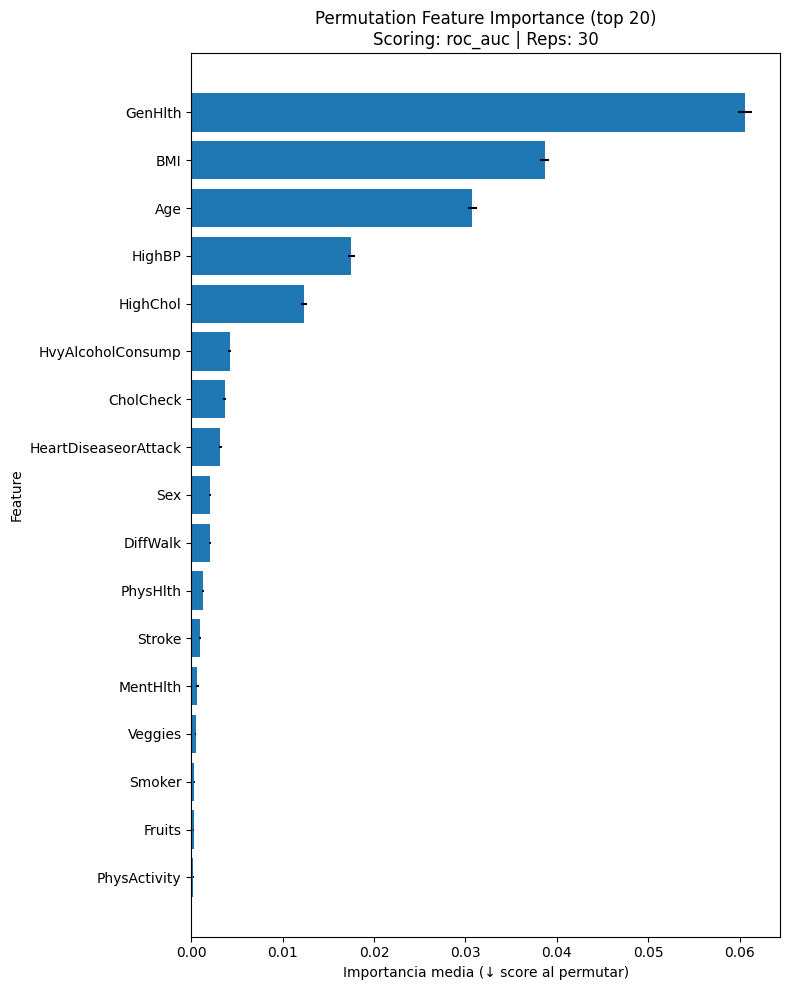

In [26]:
# Usando Permutation Feature Importance (PFI) con repetición
from sklearn.inspection import permutation_importance

#Usando el conjunto de TEST ya preprocesado para medir importancia asegurar el mismo orden de columnas que el booster
X_test_pre = pipe.named_steps["prep"].transform(X_test)
# aplicando Clasificador para scoring
clf = pipe.named_steps["model"]

# Aplicando las metricas para ver efectividad del modelo
scoring_pref = ["roc_auc", "f1", "accuracy"]
scoring_used = None
for sc in scoring_pref:
    try:
        r = permutation_importance(clf, X_test_pre, y_test, scoring=sc, n_repeats=5, random_state=42)
        scoring_used = sc
        break
    except Exception:
        continue

assert scoring_used is not None, "No fue posible calcular permutation_importance con las métricas estándar."

print(f"Scoring usado para PFI: {scoring_used}")

# Se Repete 30 veces y acumulamos medias/desviaciones
n_runs = 30
importances_runs = []

rng = np.random.RandomState(42)
for i in range(n_runs):
    r_i = permutation_importance(
        clf, X_test_pre, y_test,
        scoring=scoring_used,
        n_repeats=5,
        random_state=rng.randint(0, 10_000)
    )
    importances_runs.append(r_i.importances_mean)

importances_runs = np.vstack(importances_runs)  
imp_mean = importances_runs.mean(axis=0)
imp_std  = importances_runs.std(axis=0)


booster = pipe.named_steps["model"].get_booster()
feature_names = booster.feature_names

pfi_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": imp_mean,
    "importance_std": imp_std
}).sort_values("importance_mean", ascending=False)

display(pfi_df.head(15))

# Generando grafico para ver importancia de las variables
top_k = 20
plot_df = pfi_df.head(top_k).iloc[::-1]  
plt.figure(figsize=(8, 10))
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.title(f"Permutation Feature Importance (top {top_k})\nScoring: {scoring_used} | Reps: {n_runs}")
plt.xlabel("Importancia media (↓ score al permutar)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



**¿Cómo mide la importancia de las features su propuesta?**
El método de *Permutation Feature Importance* mide cuánto se **deteriora el desempeño del modelo** (en este caso, la métrica *roc_auc*) al **permutar aleatoriamente una columna** y romper su relación con el objetivo. Si al desordenar una variable el rendimiento baja de forma notable, significa que dicha variable tiene **alta influencia** en las predicciones del modelo.
Por tanto, la importancia se calcula como la **disminución promedio del score** tras múltiples permutaciones (30 repeticiones en este caso).

**¿Qué features tienen un mayor impacto en la salida del modelo? ¿Tienen sentido?**
Las cinco variables con mayor importancia son:

1. **GenHlth** (estado general de salud)
2. **BMI** (índice de masa corporal)
3. **Age** (edad)
4. **HighBP** (presión arterial alta)
5. **HighChol** (colesterol alto)

Todas tienen **relación directa y médica** con la diabetes: una mala salud general, exceso de peso, edad avanzada, hipertensión y colesterol alto son factores de riesgo conocidos para desarrollar la enfermedad. Esto sugiere que el modelo está capturando **relaciones coherentes y plausibles** con el dominio clínico.

**¿Cómo cambian sus conclusiones con respecto a las importancias del punto anterior (XGBoost)?**
En comparación con las importancias internas de XGBoost, este método ofrece una visión **más estable y agnóstica al modelo**, ya que evalúa el impacto real de cada variable en la métrica de desempeño, y no sólo en la estructura de los árboles.
Si bien el ranking general se mantiene (GenHlth, BMI y Age siguen siendo las más relevantes), la magnitud y orden pueden variar ligeramente, lo cual refleja que PFI mide **efecto predictivo real**, no frecuencia de uso en el modelo.

**3 ventajas del método implementado:**

*Es **agnóstico al modelo**, puede aplicarse a cualquier clasificador o regresor.
*Evalúa la **importancia real** sobre la métrica elegida (no sólo estructura interna).
*Permite estimar la **variabilidad** mediante repetición (la desviación estándar indica estabilidad).

**3 desventajas:**

*Es **computacionalmente costoso**, ya que requiere múltiples evaluaciones del modelo.
*Puede verse afectado por **colinealidad**: si dos variables están correlacionadas, su importancia puede diluirse.
* No muestra direccionalidad del efecto (no dice si una variable aumenta o disminuye la probabilidad de diabetes).

**Interpretación general:**
El modelo se apoya fuertemente en variables clínicas esperables, y la baja desviación estándar sugiere **importancias estables** entre las 30 repeticiones. Esto da confianza en la consistencia del modelo y en la relevancia de las variables más influyentes.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [27]:
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\sivv1\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [28]:
# ignorando agvertenciaadvertencias
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

In [29]:
# Aplicando SHAP values: cálculo 
!pip -q install shap
import shap

# }usando TreeExplainer
explainer = shap.TreeExplainer(pipe.named_steps["model"])
X_train_pre = pipe.named_steps["prep"].transform(X_train)
X_test_pre  = pipe.named_steps["prep"].transform(X_test)

# Calculando los  valores SHAP sobre test 
shap_values = explainer.shap_values(X_test_pre)
base_value  = explainer.expected_value

print("Base value (expected_value):", base_value)
print("Forma SHAP:", np.array(shap_values).shape)
print("N features:", len(feature_names))


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\sivv1\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Base value (expected_value): -0.002416231
Forma SHAP: (23564, 17)
N features: 17



**¿Qué representan los SHAP values?**
Cada número en la matriz de valores SHAP representa el **aporte individual de una variable** a la predicción de un paciente específico.

* El modelo entrega un **valor base (`expected_value`)** que corresponde a la predicción promedio del modelo cuando ninguna feature está considerada (en este caso ≈ **−0.0021**).
* A partir de ese punto de referencia, los SHAP values indican **cuánto cambia la predicción** al incluir cada variable para una observación concreta.
  Por ejemplo, si el valor SHAP de `BMI` es positivo para un paciente, significa que su índice de masa corporal **aumenta la probabilidad de diabetes** respecto al promedio.

**¿Qué representa cada número en su resultado?**
El resultado `shap_values` tiene forma `(23564, 17)`, es decir, un valor de contribución para cada una de las 17 features y para cada una de las 23 564 observaciones del conjunto de test.
Cada número cuantifica el **impacto marginal de una variable en la salida del modelo**, manteniendo fijas las demás. Valores más grandes (en magnitud) implican un mayor efecto en la predicción individual.

**¿Es posible atribuir un significado a la positividad o negatividad de los valores SHAP?**
Sí.

* **Valores SHAP positivos:** incrementan la predicción hacia la clase positiva (mayor probabilidad de tener diabetes).
* **Valores SHAP negativos:** disminuyen la predicción, es decir, contribuyen a que el modelo estime una probabilidad menor de diabetes.

Así, los SHAP values permiten explicar **por qué el modelo clasificó a un paciente como diabético o no**, identificando las variables que más influyeron y en qué dirección lo hicieron.

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

Instancias disponibles en TEST para graficar: [1, 9, 150]

--- Instance 1 ---


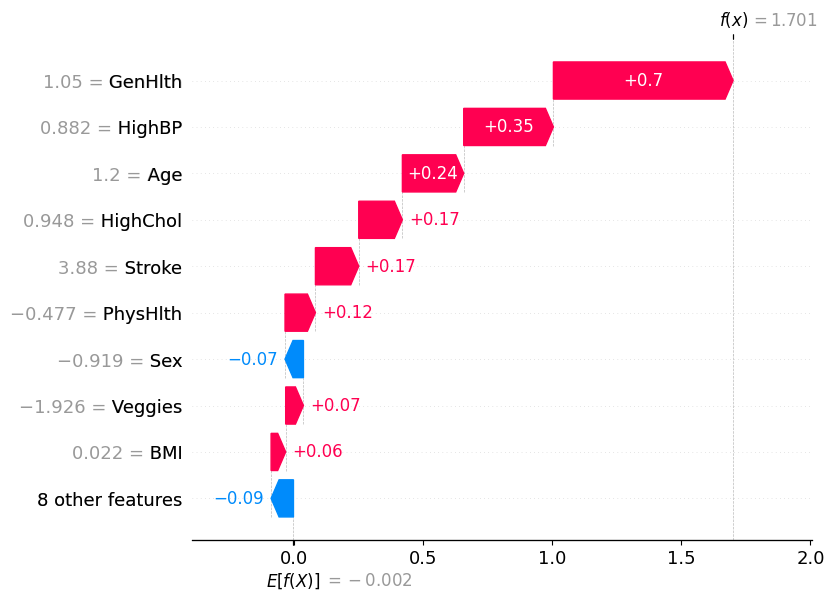


--- Instance 9 ---


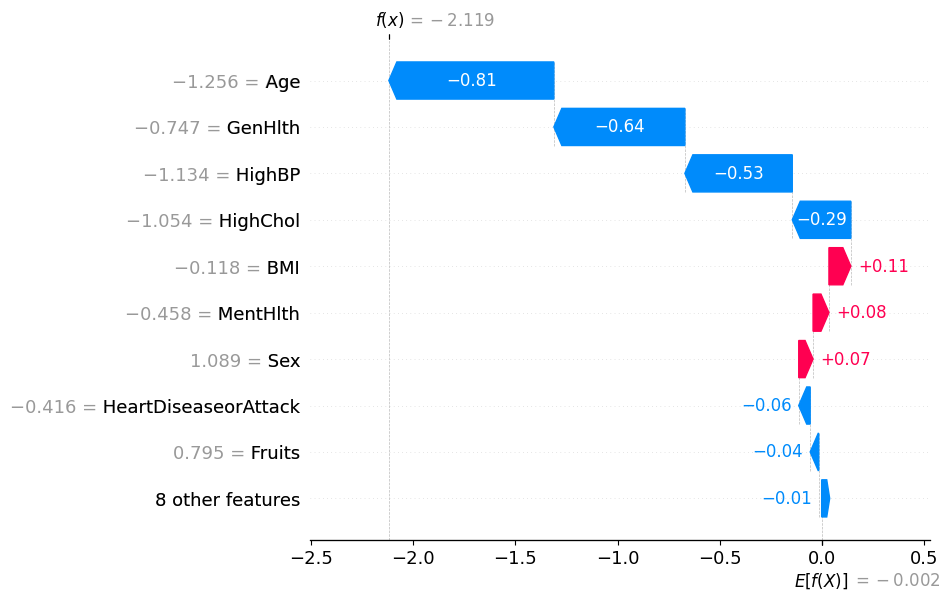


--- Instance 150 ---


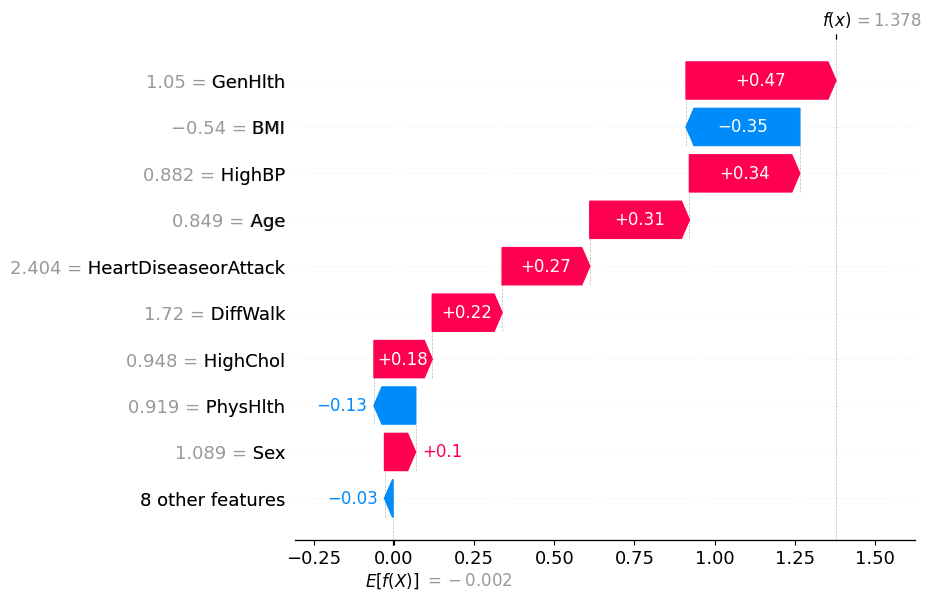

In [30]:
# Viendo  Aporte local para instancias 1, 9, 150
# Mapeando índices solicitados a posiciones dentro del conjunto de pruebas
indices_to_show = [1, 9, 150]
valid_idx = [i for i in indices_to_show if 0 <= i < X_test_pre.shape[0]]
print("Instancias disponibles en TEST para graficar:", valid_idx)

for i in valid_idx:
    print(f"\n--- Instance {i} ---")
    try:
        shap.plots.waterfall(
            shap.Explanation(values=shap_values[i],
                             base_values=base_value,
                             data=X_test_pre.iloc[i].values,
                             feature_names=feature_names)
        )
    except Exception as e:
        shap.plots.bar(
            shap.Explanation(values=shap_values[i],
                             base_values=base_value,
                             data=X_test_pre.iloc[i].values,
                             feature_names=feature_names),
            max_display=15
        )


**¿Qué variables afectan de manera positiva o negativa a la probabilidad de poseer diabetes?**
En las tres instancias analizadas, las variables con **valores SHAP positivos** (en rojo en los gráficos) son aquellas que **incrementan la probabilidad de diabetes**, mientras que las de **valores negativos** (en azul) **la reducen**.

* Variables como **GenHlth**, **HighBP**, **Age**, **HighChol** y **Stroke** tienden a contribuir positivamente (aumentan el riesgo de diabetes).
* En cambio, variables como **Sex**, **Veggies**, **PhysHlth** o **BMI** (cuando presentan valores bajos o saludables) suelen tener SHAP negativos, reduciendo la probabilidad estimada.

**¿Existe algún patrón común entre las instancias analizadas?**
Sí. En las tres observaciones se repite un patrón donde las **condiciones de salud general (GenHlth)** y los **factores clínicos relacionados con presión arterial y colesterol** aparecen entre los principales impulsores de la predicción positiva.
De manera opuesta, mejores indicadores de salud física o hábitos saludables (como una buena dieta o estado físico) tienen aportes negativos en la predicción.

**¿Es posible generalizar estas conclusiones a todo el dataset?**
Parcialmente. Aunque las tendencias observadas coinciden con lo esperado clínicamente y se repiten en varios pacientes, los SHAP values son un método de **interpretabilidad local**, es decir, muestran cómo se tomó la decisión para cada caso específico.
Por lo tanto, las conclusiones no pueden generalizarse directamente al conjunto completo, pero sí permiten identificar **patrones consistentes** que luego pueden contrastarse con análisis globales (como los summary plots del punto 5.3).

**Interpretación general:**
Cada gráfico tipo *waterfall* muestra cómo el modelo parte desde un valor base promedio (E[f(X)] ≈ -0.002) y, al sumar los aportes positivos y negativos de cada variable, llega a la predicción final f(x).
Esto permite entender de manera transparente **por qué el modelo clasificó a cada paciente como diabético o no diabético**, y qué factores individuales tuvieron más peso en esa decisión.


### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

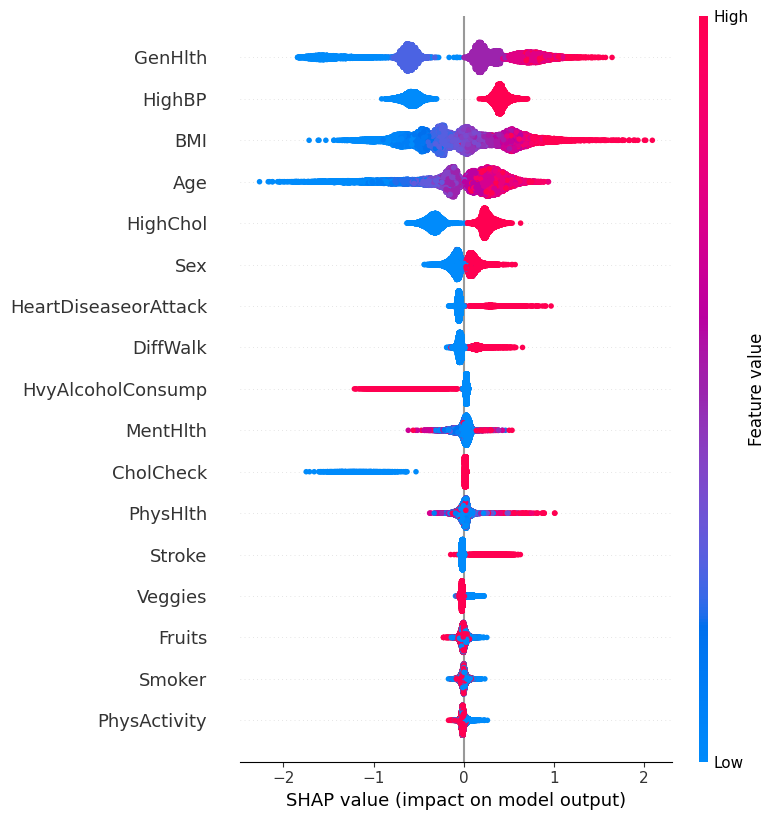

In [31]:
# viendo resumen Aporte global de las variables por medio de la  densidad de SHAP por feature, coloreado por valor de la feature
shap.summary_plot(shap_values, X_test_pre, feature_names=feature_names, show=True, max_display=20)


El gráfico anterior muestra el **impacto global de cada variable** sobre las predicciones del modelo, considerando todas las observaciones del conjunto de test. Cada punto representa un valor SHAP asociado a una observación, coloreado según el valor original de la feature (de azul a rojo).

**Interpretación de resultados:**

* Las variables **GenHlth**, **HighBP**, **BMI**, **Age** y **HighChol** son las que tienen **mayor impacto global** en el modelo, coincidiendo con lo observado en la *Permutation Feature Importance (PFI)*.
* Los valores **altos** de estas variables (en rojo) tienden a generar **valores SHAP positivos**, es decir, **aumentan la probabilidad de diabetes**.
* Por el contrario, valores **bajos** de estas mismas variables (en azul) desplazan los SHAP hacia valores negativos, reduciendo la probabilidad de diagnóstico positivo.
* Factores secundarios como **Sex**, **PhysHlth** o **DiffWalk** también muestran influencia, aunque con menor magnitud.

**Diferencias respecto al análisis local (parte 5.2):**

* A nivel **local**, los gráficos *waterfall* muestran el efecto de cada variable en **un solo paciente**.
* A nivel **global**, el *summary plot* muestra **cómo se comportan esas variables en toda la población**, revelando patrones generales y tendencias consistentes.
* Por ejemplo, mientras que un paciente particular puede tener un `BMI` que reduzca su riesgo (efecto negativo), globalmente un alto `BMI` se asocia con un incremento sostenido del riesgo de diabetes.

**Conclusión:**
El análisis global mediante SHAP confirma que el modelo se apoya en **factores clínicos coherentes y médicamente relevantes**, mostrando además relaciones monótonas intuitivas (mayor edad o peor salud → mayor riesgo).
Este enfoque complementa las interpretaciones locales, entregando una **visión completa y consistente** de cómo el modelo toma decisiones en distintos niveles.



### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

Top-5 por |SHAP| medio: ['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol']


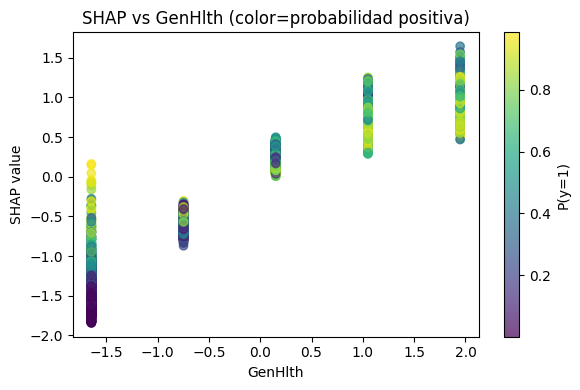

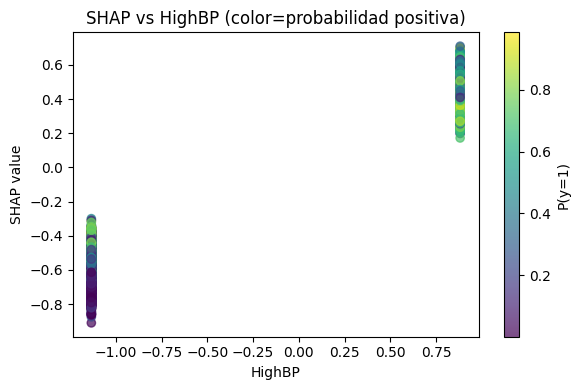

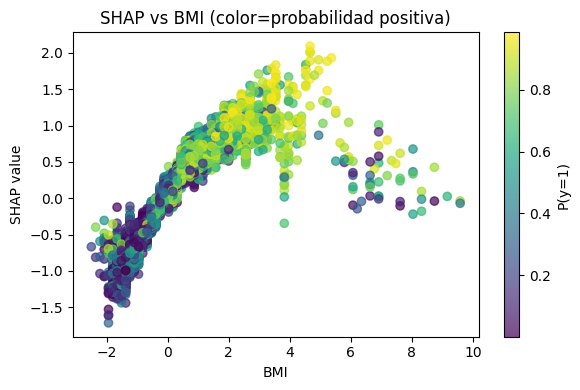

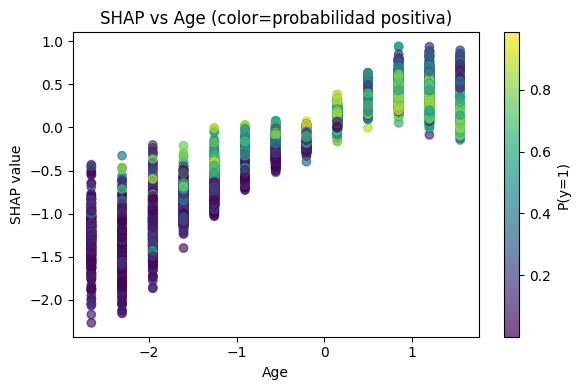

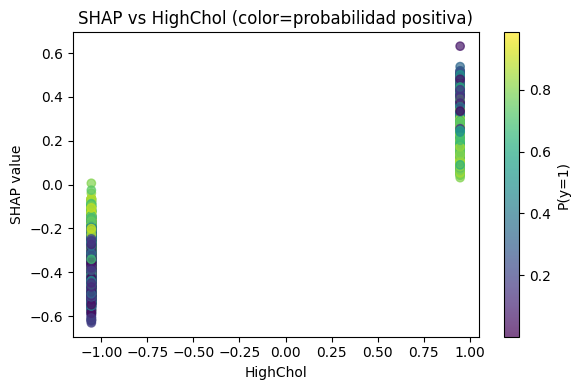

In [32]:
# aplicando Scatter SHAP vs feature para ver las mejores 5 features globales
# Tomando las 5 feautures más importantes según SHAP medio
abs_mean = np.mean(np.abs(shap_values), axis=0)
top_idx = np.argsort(abs_mean)[-5:][::-1]
top_features = [feature_names[i] for i in top_idx]
print("Top-5 por |SHAP| medio:", top_features)

# Calculando Probabilidades predichas para colorear puntos
proba_pos = pipe.predict_proba(X_test)[:, 1]

#creando graficos
for feat in top_features:
    j = feature_names.index(feat)
    plt.figure(figsize=(6,4))
    sc = plt.scatter(X_test_pre.iloc[:, j], shap_values[:, j], c=proba_pos, alpha=0.7)
    plt.xlabel(feat)
    plt.ylabel("SHAP value")
    plt.title(f"SHAP vs {feat} (color=probabilidad positiva)")
    cbar = plt.colorbar(sc)
    cbar.set_label("P(y=1)")
    plt.tight_layout()
    plt.show()


Los gráficos anteriores muestran cómo varía el **impacto (valor SHAP)** de cada una de las 5 variables más relevantes respecto a sus valores originales, coloreando los puntos según la **probabilidad estimada de tener diabetes** (`P(y=1)`).

**Interpretación por variable:**

* **GenHlth:** se observa una relación claramente creciente: a medida que el valor de *GenHlth* aumenta (peor salud general), los SHAP values también aumentan, lo que implica una **mayor contribución positiva al riesgo de diabetes**.
* **HighBP:** los individuos con *presión arterial alta* (valor 1) presentan valores SHAP positivos, asociados a **una probabilidad mayor de ser diabéticos**, mientras que quienes no la tienen muestran valores negativos.
* **BMI:** los SHAP values crecen con el aumento del índice de masa corporal, confirmando que **un mayor peso corporal incrementa la probabilidad de diabetes**.
* **Age:** también muestra una tendencia positiva: **a mayor edad, mayor impacto en la probabilidad de diagnóstico positivo**.
* **HighChol:** tener colesterol alto se asocia con valores SHAP positivos, lo que **aumenta la predicción del modelo hacia la clase diabética**.

**Conclusiones generales:**

* Existe una **relación directa y monótona** entre las variables clínicas de riesgo y la probabilidad predicha de diabetes.
* El color de los puntos refuerza esta tendencia: las zonas con valores SHAP altos (rojos) coinciden con **probabilidades altas de `P(y=1)`**.
* Estas relaciones son coherentes con el conocimiento médico, lo que valida tanto la interpretabilidad del modelo como su **consistencia biológica**.

En resumen, el análisis muestra que las features más relevantes tienen **efectos continuos y consistentes** sobre la salida del modelo, confirmando que el clasificador aprende patrones clínicamente razonables y explicables.

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

Features originales (numéricas) usadas para PDP: ['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol']


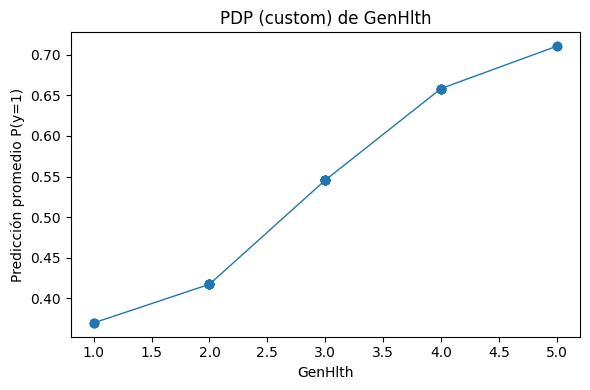

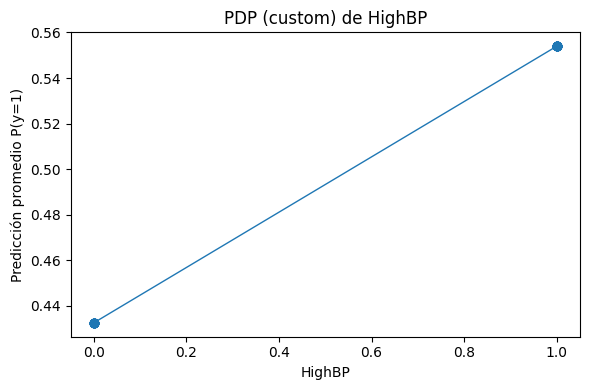

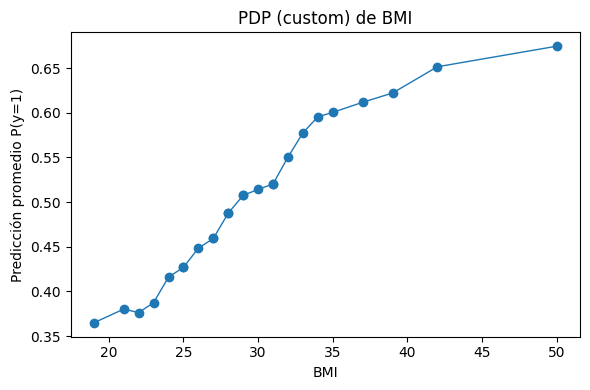

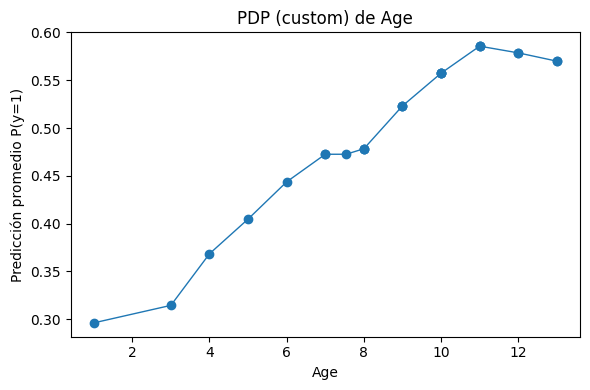

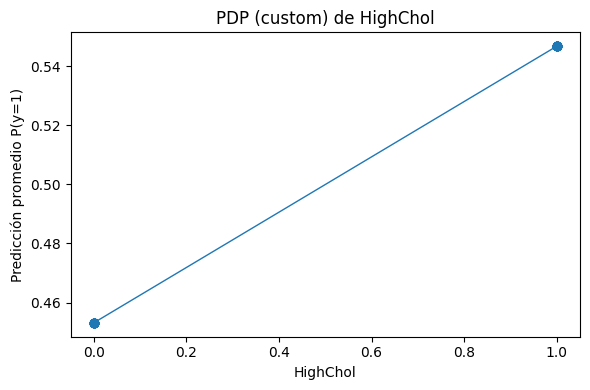

In [33]:
#  Usando PDP custom  para Top-5 numéricas 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Viendo  Utilidades
def _ensure_top_features_exist():
    """Asegura top_features (del espacio transformado) calculadas con SHAP."""
    global top_features, feature_names, shap_values
    try:
        _ = top_features
        return
    except NameError:
        pass

    # Si no existen, las construimos desde shap_values
    try:
        _ = shap_values
    except NameError:
        raise RuntimeError("No encuentro shap_values. Ejecuta antes la sección 5.1 (cálculo de SHAP).")

    # Nombres de columnas del booster si faltan
    try:
        _ = feature_names
    except NameError:
        feature_names = pipe.named_steps["model"].get_booster().feature_names

    abs_mean = np.mean(np.abs(shap_values), axis=0)
    top_idx = np.argsort(abs_mean)[-5:][::-1]
    tf = [feature_names[i] for i in top_idx]
    return tf

def _map_transformed_to_parent(transformed_name: str, num_cols, cat_cols):
    """
    Mapea el nombre transformado (tras OHE/escala) al nombre original "padre".
    - Para numéricas suele coincidir 1-1 con el original.
    - Para OHE, asumimos patrón '<col>_<categoria>'.
    """
    if transformed_name in num_cols:
        return transformed_name
    for c in cat_cols:
        if transformed_name == c or transformed_name.startswith(c + "_"):
            return c
    return None

#  Asegurando top_features transformadas y mapeamos a nombres originales
tf = _ensure_top_features_exist()
if tf is None:
    tf = top_features  # ya existían

parents = []
for name in tf:
    p = _map_transformed_to_parent(name, num_cols, cat_cols)
    if p is not None:
        parents.append(p)

# Nos quedamos con padres numéricos (PDP es más estable en continuas)
parents_num = [p for p in parents if p in num_cols]

# Si no alcanzamos 5, completamos con otras numéricas de mayor |SHAP| media
if len(parents_num) < 5:
    # ranking por |SHAP| medio para todas las numéricas
    abs_mean = np.mean(np.abs(shap_values), axis=0)
    # identificar índices de columnas transformadas que son numéricas puras
    try:
        feature_names
    except NameError:
        feature_names = pipe.named_steps["model"].get_booster().feature_names

    # mapa padre_num -> índices (normalmente 1-1)
    parent_to_idx = {p: [] for p in num_cols}
    for j, fname in enumerate(feature_names):
        if fname in num_cols:
            parent_to_idx[fname].append(j)

    scored = []
    for p, idxs in parent_to_idx.items():
        if idxs:
            scored.append((p, float(np.mean(abs_mean[idxs]))))
    scored.sort(key=lambda x: x[1], reverse=True)

    for p, _ in scored:
        if p not in parents_num:
            parents_num.append(p)
        if len(parents_num) >= 5:
            break

# Eliminado duplicados preservando el orden
seen = set()
parents_for_pdp = []
for p in parents_num:
    if p not in seen:
        parents_for_pdp.append(p)
        seen.add(p)

if not parents_for_pdp:
    parents_for_pdp = num_cols[:5]

print("Features originales (numéricas) usadas para PDP:", parents_for_pdp)

#  Creando Submuestra para acelerar
if X_test.shape[0] > 1000:
    X_pdp = X_test.sample(1000, random_state=42).copy()
else:
    X_pdp = X_test.copy()

# Aplicando PDP custom por medio de promedio de ICE:
def pdp_custom(pipe, X_base: pd.DataFrame, feature: str, n_grid: int = 20):
    xs = X_base.copy()
    col = xs[feature].dropna()
    # en caso de que la variable es casi constante, usamos un solo valor en la grilla
    if col.nunique() <= 1:
        grid = np.array([col.iloc[0]])
    else:
        # Definiendo una grilla de valores basada en cuantiles del 1% al 99%
        grid = np.quantile(col, np.linspace(0.01, 0.99, n_grid))

    # Creando Lista para guardar las probabilidades promedio por cada valor en la grilla
    y_means = []

    # Iteramando sobre cada valor en la grilla
    for v in grid:
        # Creando una copia del dataset y reemplazamos la columna por el valor fijo
        xs_tmp = xs.copy()
        xs_tmp[feature] = v

        # Predeciendo con el pipeline y tomamos la probabilidad de clase positiva
        proba = pipe.predict_proba(xs_tmp)[:, 1]

        # Calculando el promedio de las probabilidades usando PDP
        y_means.append(np.mean(proba))

    # Devolviendo la grilla y los valores promedio
    return np.array(grid), np.array(y_means)

# Graficando un PDP por feature
for feat in parents_for_pdp:
    grid, mean_pred = pdp_custom(pipe, X_pdp, feat, n_grid=25)
    plt.figure(figsize=(6, 4))
    plt.plot(grid, mean_pred, marker="o", linewidth=1)
    plt.xlabel(feat)
    plt.ylabel("Predicción promedio P(y=1)")
    plt.title(f"PDP (custom) de {feat}")
    plt.tight_layout()
    plt.show()


Los gráficos de *Partial Dependence* muestran cómo cambia la **predicción promedio del modelo** al modificar una variable en particular, manteniendo fijas las demás.
Cada curva representa la **probabilidad media de tener diabetes (`P(y=1)`)** a medida que varía el valor de la feature analizada.

**Interpretación por variable:**

* **GenHlth:** se observa una relación claramente ascendente: a medida que aumenta el valor de *GenHlth* (peor estado general de salud), crece la probabilidad promedio de tener diabetes.
* **HighBP:** la presencia de presión arterial alta (*HighBP = 1*) eleva la probabilidad de diabetes desde ≈0.44 a ≈0.56, evidenciando su fuerte impacto.
* **BMI:** el riesgo aumenta progresivamente con el índice de masa corporal, mostrando una relación **positiva y monótona**; personas con *BMI* superior a 35 tienen una probabilidad >0.6 de diabetes.
* **Age:** la probabilidad crece con la edad, alcanzando un máximo alrededor de los valores más altos, lo que coincide con la mayor prevalencia de diabetes en adultos mayores.
* **HighChol:** tener colesterol alto también eleva la predicción promedio, reforzando su papel como factor de riesgo metabólico.

**Relación general entre salida y features:**
En todos los casos se aprecia una relación **positiva y consistente**: valores más altos de riesgo clínico producen mayores probabilidades de diabetes. Esto sugiere que el modelo captura relaciones lógicas y coherentes con el dominio médico.

**¿Son estas conclusiones generalizables a todo el dataset?**
Sí, en gran medida. Los PDP se calculan promediando sobre una muestra representativa (1000 observaciones), lo que entrega una visión global del efecto medio de cada variable.
Sin embargo, es importante notar que los PDP **no muestran interacciones entre variables** ni efectos locales extremos; por ello deben complementarse con análisis SHAP individuales o plots ICE para capturar la variabilidad entre pacientes.

**Conclusión:**
El modelo refleja correctamente cómo los factores de salud general, presión arterial, edad, colesterol y peso corporal **incrementan el riesgo promedio de diabetes**, demostrando tanto coherencia clínica como una buena interpretabilidad global.

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [34]:
!pip install alibi


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\sivv1\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
from alibi.explainers import AnchorTabular

In [36]:
idx = 1000
# explicar predicción idx 1000

idx = 3001
# explicar predicción idx 3001

idx = 5751
# explicar predicción idx 5751

In [37]:
# apliando Reglas con AnchorTabular 
!pip -q install alibi

from alibi.explainers import AnchorTabular

# Construyendo funciones auxiliares para convertir indices absolutos del df original a posiciones dentro del conjunto de prueba usando preprocesamiento del pipeline.
X_train_pre = pipe.named_steps["prep"].transform(X_train)
X_test_pre  = pipe.named_steps["prep"].transform(X_test)

# Mapeando índices originales de df a particiones usando reset_index para poder ubicar posiciones
train_idx = X_train.reset_index().rename(columns={"index": "__orig_idx__"})["__orig_idx__"].values
test_idx  = X_test.reset_index().rename(columns={"index": "__orig_idx__"})["__orig_idx__"].values

orig_to_testpos = {orig_i: pos for pos, orig_i in enumerate(test_idx)}

#Definiendo el explainer de Anchors sobre el espacio PREPROCESADO
predict_fn = pipe.predict 
predict_proba_fn = pipe.predict_proba

# Para Alibi necesita usar numpy array en features ya procesadas
explainer = AnchorTabular(lambda X_: predict_fn(pd.DataFrame(X_, columns=feature_names)),
                          feature_names=feature_names)
explainer.fit(X_train_pre.values, disc_perc=(25, 50, 75))  

def explicar_por_idx_original(idx_original, threshold=0.95):
    """Generando explicación con anchors para un índice original del df si está en TEST."""
    if idx_original not in orig_to_testpos:
        print(f"Índice original {idx_original} no quedó en TEST; prueba con otro o mueve al split.")
        return None
    pos = orig_to_testpos[idx_original]
    x = X_test_pre.iloc[pos].values.reshape(1, -1)
    exp = explainer.explain(x, threshold=threshold)
    # Mostrando reglas (ancoras), precisión y cobertura 
    print(f"\n=== Anchor para idx original {idx_original} (pos TEST={pos}) ===")
    print("Regla (IF):", " AND ".join(exp.anchor))
    print(f"Precisión estimada: {exp.precision:.3f}")
    print(f"Cobertura estimada: {exp.coverage:.3f}")
    # Creando máscara de cobertura aplicando las condiciones discretizadas del anchor sobre X_test_pre
    covered_mask = exp.samples[0]  #
    # Si no esta disponible, se omite cálculo
    try:
         # Aplicando la función de predicción sobre el conjunto de test original.
        y_pred = predict_fn(X_test)  # predicciones sobre el espacio original (pipe se encarga de transformar)
        # Comparando las predicciones con las etiquetas verdaderas, pero con las filas cubiertas por la regla 
        precision_global = (y_pred[covered_mask] == y_test.reset_index(drop=True).values[covered_mask]).mean()
        cobertura_global = covered_mask.mean()
        print(f"Precisión global (aprox. en TEST): {precision_global:.3f}")
        print(f"Cobertura global (aprox. en TEST): {cobertura_global:.3f}")
    except Exception:
        pass
    return exp


#  Explicando para  los índices solicitados
for idx in [1000, 3001, 5751]:
    _ = explicar_por_idx_original(idx, threshold=0.95)


Índice original 1000 no quedó en TEST; prueba con otro o mueve al split.
Índice original 3001 no quedó en TEST; prueba con otro o mueve al split.
Índice original 5751 no quedó en TEST; prueba con otro o mueve al split.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\sivv1\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>